In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
from tqdm import tqdm

from joblib import Parallel, delayed

import pickle

import schwingerModel as sim

from schwingerModel.interpolator import MesonOp, mesonMultiplet, makeState

In [ ]:
# with open('configs/50kSteps.pkl', 'rb') as f:
#     a1 = pickle.load(f)

In [3]:
# sim.distillation.generateDistillFile(modelObj=a1,filePath="./configs/50kSteps.hdf5",numVecs=5,autocorrSkip=50,DNums=(0,1,2),momks=(0,1,2))

In [4]:
def coshCorrel(nt, Energy, pivot,dimt):
    num = np.exp(-nt*Energy)+np.exp((nt-dimt)*Energy)
    denom = np.exp(-pivot*Energy)+np.exp((pivot-dimt)*Energy)
    return num/denom

In [5]:
def triplet(op):                       # the pi+-type member: connected-only, like the old path
    return mesonMultiplet(op, 1)[+1]

def singlet(op):                       
    return mesonMultiplet(op, 0)[0]

g5   = MesonOp("g5")
g5d2 = MesonOp("g5", DNum=2)
g5p, g5m = MesonOp("g5", 0, 1), MesonOp("g5", 0, -1)

pipi_00   = makeState([(g5,   1), (g5,   1)], I=2, I3=2)   # pi(g5)   pi(g5)
pipi_0d2  = makeState([(g5,   1), (g5d2, 1)], I=2, I3=2)   # pi(g5)   pi(g5 D2)
pipi_d2d2 = makeState([(g5d2, 1), (g5d2, 1)], I=2, I3=2)   # pi(g5D2) pi(g5D2)
pipi_k1 = makeState([(g5p,1), (g5m,1)], I=2, I3=2)      # auto parity-even, total k=0

In [6]:
path = "./configs/50kSteps.hdf5"
meta = sim.distillation.readDistillMeta(path)

basisPiPi = [pipi_00,pipi_0d2,pipi_d2d2,pipi_k1]
basisPi = [triplet(g5), triplet(g5d2)]

dataPiPi = sim.GEVP.measureEnsemble(path, meta.configIndices, basisPiPi)
dataPi = sim.GEVP.measureEnsemble(path, meta.configIndices, basisPi)

In [7]:
gevpTi = 2

out1 = sim.GEVP.bootstrapEnsemble(dataPiPi, reduce=sim.GEVP.makeGevpReduce(ti=gevpTi,shift=1))
out2 = sim.GEVP.bootstrapEnsemble(dataPi, reduce=sim.GEVP.makeGevpReduce(ti=gevpTi,shift=1))

In [8]:
pipiE = []
for i in range(len(basisPiPi)):
    pipiE.append(sim.GEVP.gevpMassExtract(out1,fitT=[4,10],eigenIdx=i,coshExpr=False))

pipiE = np.array(pipiE)

In [9]:
print(pipiE)

[[1.30626108e+00 8.20646073e-04]
 [1.83007272e+00 5.17334866e-04]
 [1.87600140e+00 2.87658858e-03]
 [2.48575026e+00 3.92505689e-03]]


(1.0, 16.0)

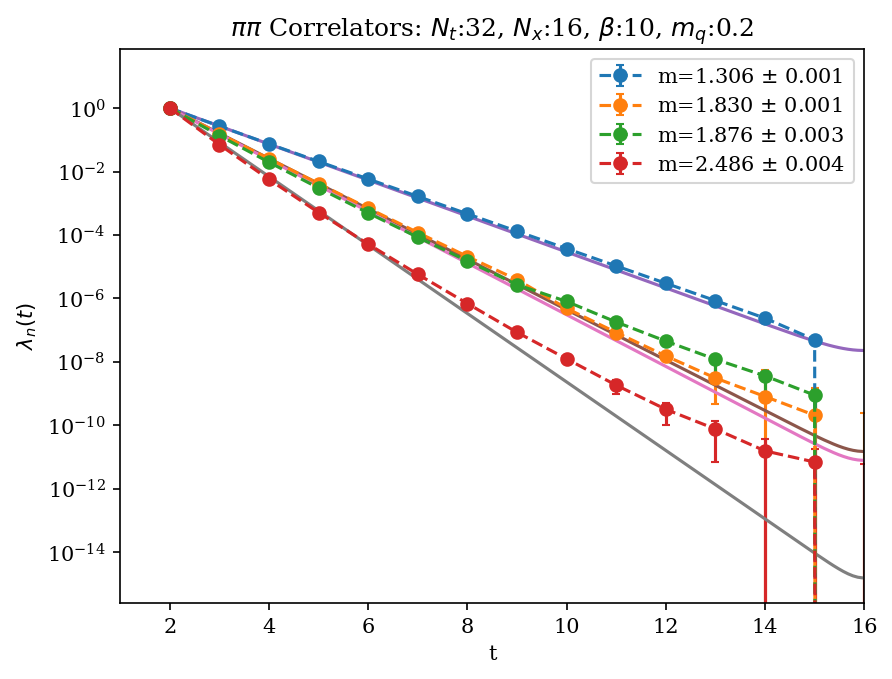

In [10]:
central, err, cov = out1

ts = np.arange(gevpTi, gevpTi + central.shape[0])   # actual times: gevpTi .. dimt-1

plt.figure(dpi=150)
for e in range(central.shape[1]):
    plt.errorbar(ts, central[:, e], yerr=err[::-1, :, e],
                 fmt='o--', capsize=2, label=rf"m={pipiE[e,0]:.3f} $\pm$ {pipiE[e,1]:.3f}")

# cosh references: same pivot as the gevp normalization, explicit x-axis
tf = np.linspace(gevpTi, meta.dimt - 1, 300)

for i in range(len(basisPiPi)):
    plt.plot(tf, coshCorrel(tf, pipiE[i][0], gevpTi, meta.dimt))


plt.semilogy()
plt.xlabel("t"); plt.ylabel(r"$\lambda_n(t)$")
plt.legend()

plt.title(rf"$\pi\pi$ Correlators: $N_t$:{meta.dimt}, $N_x$:{meta.dimx}, $\beta$:{meta.beta}, $m_q$:{meta.fMass}")

plt.xlim([1,16])

In [11]:
piE = []
for i in range(len(basisPi)):
    piE.append(sim.GEVP.gevpMassExtract(out2,fitT=[4,10],eigenIdx=i,coshExpr=False))

piE = np.array(piE)

In [12]:
print(piE)

[[5.87247461e-01 3.88021269e-04]
 [1.28119461e+00 1.74115615e-03]]


(1.0, 16.0)

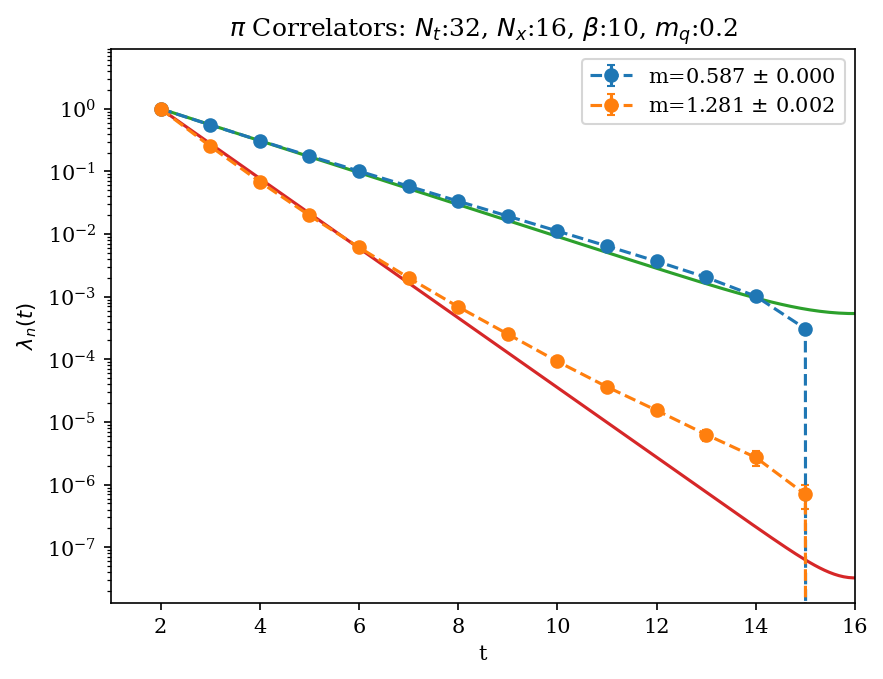

In [13]:
central, err, cov = out2

ts = np.arange(gevpTi, gevpTi + central.shape[0])   # actual times: gevpTi .. dimt-1

plt.figure(dpi=150)
for e in range(central.shape[1]):
    plt.errorbar(ts, central[:, e], yerr=err[::-1, :, e],
                 fmt='o--', capsize=2, label=rf"m={piE[e,0]:.3f} $\pm$ {piE[e,1]:.3f}")

# cosh references: same pivot as the gevp normalization, explicit x-axis
tf = np.linspace(gevpTi, meta.dimt - 1, 300)

for i in range(len(basisPi)):
    plt.plot(tf, coshCorrel(tf, piE[i][0], gevpTi, meta.dimt))


plt.semilogy()
plt.xlabel("t"); plt.ylabel(r"$\lambda_n(t)$")
plt.legend()

plt.title(rf"$\pi$ Correlators: $N_t$:{meta.dimt}, $N_x$:{meta.dimx}, $\beta$:{meta.beta}, $m_q$:{meta.fMass}")

plt.xlim([1,16])

In [14]:
basisEta = [singlet(g5),singlet(g5d2)]

dataEta = sim.GEVP.measureEnsemble(path, meta.configIndices, basisEta)

In [15]:
outEta = sim.GEVP.bootstrapEnsemble(dataEta, reduce=sim.GEVP.makeGevpReduce(ti=gevpTi,shift=1))

In [16]:
etaE = []
for i in range(len(basisEta)):
    etaE.append(sim.GEVP.gevpMassExtract(outEta,fitT=[4,10],eigenIdx=i,coshExpr=False))

etaE = np.array(etaE)

In [17]:
print(etaE)

[[0.60244661 0.00193898]
 [1.28127616 0.00352765]]


(1.0, 16.0)

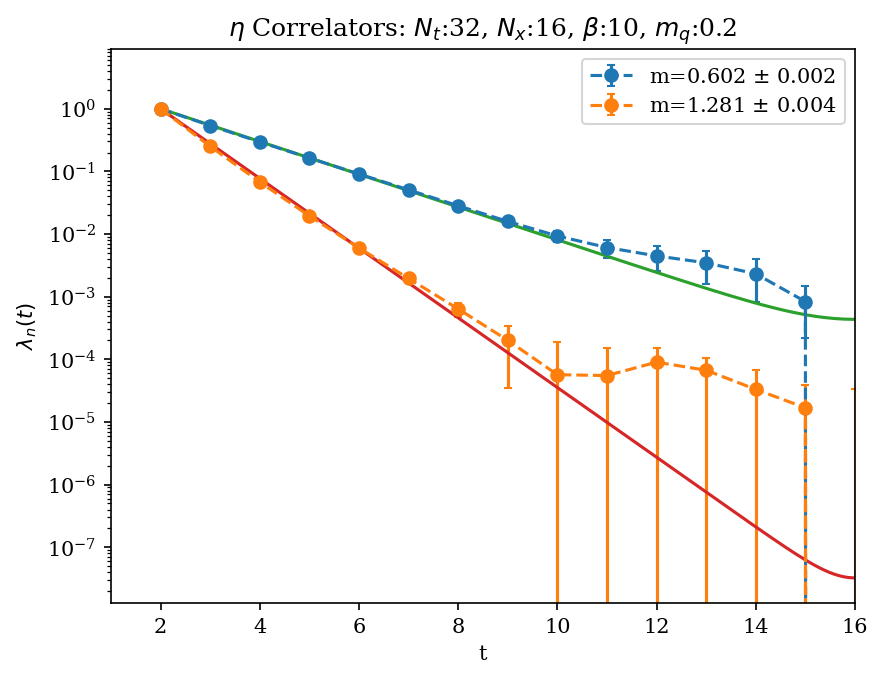

In [18]:
central, err, cov = outEta

ts = np.arange(gevpTi, gevpTi + central.shape[0])   # actual times: gevpTi .. dimt-1

plt.figure(dpi=150)
for e in range(central.shape[1]):
    plt.errorbar(ts, central[:, e], yerr=err[::-1, :, e],
                 fmt='o--', capsize=2, label=rf"m={etaE[e,0]:.3f} $\pm$ {etaE[e,1]:.3f}")

# cosh references: same pivot as the gevp normalization, explicit x-axis
tf = np.linspace(gevpTi, meta.dimt - 1, 300)

for i in range(len(basisPi)):
    plt.plot(tf, coshCorrel(tf, etaE[i][0], gevpTi, meta.dimt))


plt.semilogy()
plt.xlabel("t"); plt.ylabel(r"$\lambda_n(t)$")
plt.legend()

plt.title(rf"$\eta$ Correlators: $N_t$:{meta.dimt}, $N_x$:{meta.dimx}, $\beta$:{meta.beta}, $m_q$:{meta.fMass}")

plt.xlim([1,16])

In [19]:
etaeta_00   = makeState([(g5,   0), (g5,   0)], I=0, I3=0)   
etaeta_0d2  = makeState([(g5,   0), (g5d2, 0)], I=0, I3=0)   
etaeta_d2d2 = makeState([(g5d2, 0), (g5d2, 0)], I=0, I3=0)   
etaeta_k1 =   makeState([(g5p,  0), (g5m,  0)], I=0, I3=0)      # auto parity-even, total k=0

basisEtaEta = [etaeta_00,etaeta_0d2,etaeta_d2d2,etaeta_k1]

dataEtaEta = sim.GEVP.measureEnsemble(path, meta.configIndices, basisEtaEta)

In [68]:
outEtaEta = sim.GEVP.bootstrapEnsemble(dataEtaEta, reduce=sim.GEVP.makeGevpReduce(ti=gevpTi,shift=1))

In [74]:
etaetaE = []
for i in range(4):
    etaetaE.append(sim.GEVP.gevpMassExtract(outEtaEta,fitT=[2,5],eigenIdx=i,coshExpr=False))

etaetaE = np.array(etaetaE)
# etaetaE = np.vstack([etaetaE,np.zeros((1,2))])

In [75]:
print(etaetaE)

[[1.14943905e+00 1.18178814e-03]
 [1.25552658e+00 1.85397522e-03]
 [1.52029112e+00 2.64674074e-02]
 [1.84553252e+00 2.97842246e-03]]


(1.0, 16.0)

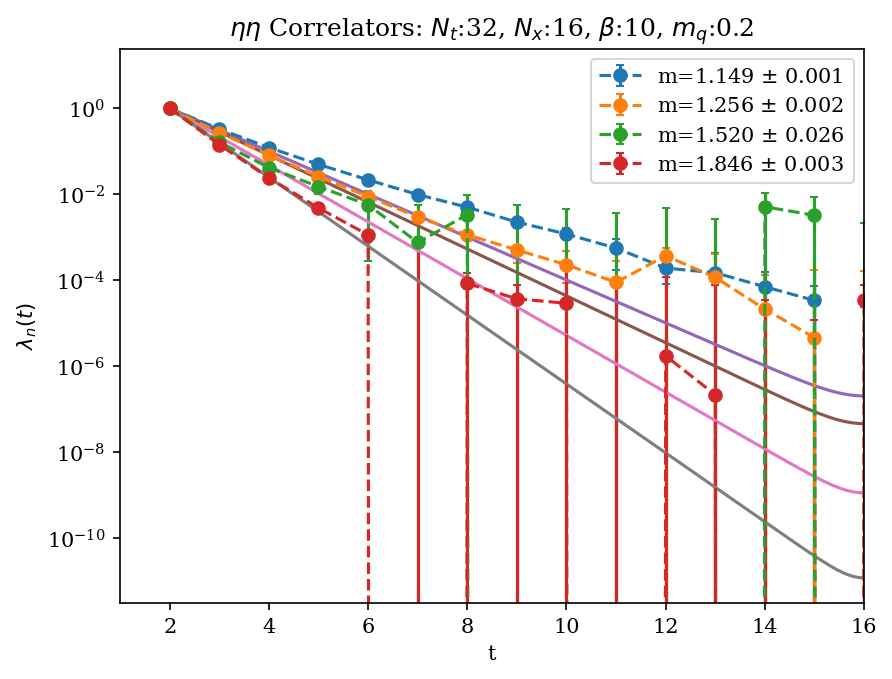

In [78]:
central, err, cov = outEtaEta

ts = np.arange(gevpTi, gevpTi + central.shape[0])   # actual times: gevpTi .. dimt-1

plt.figure(dpi=150)
for e in range(central.shape[1]):
    plt.errorbar(ts, central[:, e], yerr=np.abs(err[::-1, :, e]),
                 fmt='o--', capsize=2, label=rf"m={etaetaE[e,0]:.3f} $\pm$ {etaetaE[e,1]:.3f}")

# cosh references: same pivot as the gevp normalization, explicit x-axis
tf = np.linspace(gevpTi, meta.dimt - 1, 300)

for i in range(4):
    plt.plot(tf, coshCorrel(tf, etaetaE[i][0], gevpTi, meta.dimt))


plt.semilogy()
plt.xlabel("t"); plt.ylabel(r"$\lambda_n(t)$")
plt.legend()

plt.title(rf"$\eta \eta$ Correlators: $N_t$:{meta.dimt}, $N_x$:{meta.dimx}, $\beta$:{meta.beta}, $m_q$:{meta.fMass}")

plt.xlim([1,16])